# Recurrent Neural Networks

Here are the papers link that I'm using as my source: https://arxiv.org/abs/1412.3555 and https://arxiv.org/abs/1308.0850

Along with that I'm digging some information from Karpathy's old blog post: https://karpathy.github.io/2015/05/21/rnn-effectiveness/

## Unstructured RNN Notes
- In a standard feedforward network, each input is treated as independent. But that doesn't bode well with data like sentences or sequences where the previous inputs help define the expected outputs. 
- RNNs can handle variable-length inputs
- The RNN's recurrent hidden stats are updated by: $\mathbf{h}_t = \begin{cases} 0, & t=0 \\ \phi\left(\mathbf{h}_{t-1}, \mathbf{x}_t\right), & \text{otherwise} \end{cases}$
    - Here $\phi$ is pretty much a neuron, some affine transformation followed by nonlinear activation function
    - The equation above is usually implemented as $h_t = g(Wx_t + Uh_{t-1})$
- Generative RNNs output a probability distribution of the next element in the sequence using the hidden state.
    - The sequence has variable length because we use an of sequence symbol that represents the end of the sequence
    - We decompose the sequence probability as $p(x_1,\dots,x_T)=p(x_1)p(x_2|x_1)p(x_3|x_1,x_2)\dots p(x_T|x_1,\dots, x_{T-1})$
- RNN's are unable to store information about past inputs for very long
- Since RNN's reuse their predictions (during inference), they can't really recover from their mistakes
    - I recently created my "Topology" notebook and this quote was cool to see since I've just learned about this: *"The
problem of instability is especially acute with real-valued data, where it is easy
for the predictions to stray from the manifold on which the training data lies."*
        - Since the model uses its outputs as its inputs, it is rather common for it to receive an input that does not match the training data and hence is off the manifold on which the training data lies
- During training we use **teacher forcing** where we feed the correct inputs and not the model's outputs. Otherwise it will struggle to learn, especially when it is rather weak.
- When I was viewing diagrams I got a tad confused over the unrolled vs. compact diagrams of the same network. Note that you can display a network in multiple ways.
- A big issue with RNNs is vanishing/exploding gradient.
    - Since we reuse the hidden states, not only does a hidden state determine the output, it also affects the next hidden state (which in turn affects the output and the next hidden state and so on...).
    - So the gradient of an early hidden state is proportional to the term $W_h^n$ (weights for the hidden state, also written as $U_h^k$) where $n$ is the number of layers until the output. Through eigendecomposition you can state that $W_h^n = V \Lambda^n V^{-1}$ where $\Lambda$ consists of eigenvalues. If $\lambda <1$ then the gradient shrinks and if $\lambda >1$ gradient explodes
        - My intuition here is that you could define the weight matrix $W_h$ to always be orthogonal, so that $|\lambda|=1$ at the price of fewer degrees of freedom for the weights. And this has actually been done apparently, kind of cool. Another trick is to initialize RNN weights for this matrix to be orthogonal, so the early training will be stable.  


## Code

I'm going to use the Autograd engine that I built by hand for the RNN portion of this notebook. It will look a little ugly since my implementation only really works with vectors, so there is a lot of ugliness that we have to deal with to make this work. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
rng = np.random.default_rng(seed=42)

In [2]:
class Node:
    def __init__(self, val, parents=[], operation=""):
        self.val = val
        self.parents = parents
        self.gradient = 0.0
        self.operation = operation

    def __add__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val + other_node.val, parents=[self,other_node],operation="+")
        return new_node

    def __mul__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val * other_node.val, parents=[self,other_node],operation="*")
        return new_node

    def __truediv__(self,other_node):
        new_node = Node(self.val / other_node.val, parents=[self,other_node],operation="/")
        return new_node

    def exp(self):
        return Node(np.exp(self.val),parents=[self], operation="exp")

    def log(self):
        return Node(np.log(self.val + 1e-15),parents=[self], operation="log")

    def relu(self):
        return Node(max(0,self.val),parents=[self], operation="relu")

    def sigmoid(self):
        new_val = 1/(1+np.exp(-self.val))
        return Node(new_val,parents=[self], operation="sigmoid")

    def tanh(self):
        return Node(np.tanh(self.val), parents=[self], operation="tanh")

    def _backprop(self):
        if not self.parents:
            pass
        elif self.operation == "+":
            self.parents[0].gradient += self.gradient
            self.parents[1].gradient += self.gradient
        elif self.operation == "*":
            self.parents[0].gradient += self.gradient * self.parents[1].val
            self.parents[1].gradient += self.gradient * self.parents[0].val
        elif self.operation == "/":
            self.parents[0].gradient += self.gradient * (1/self.parents[1].val)
            self.parents[1].gradient += self.gradient * (-self.parents[0].val / (self.parents[1].val **2))
        elif self.operation == "relu":
            self.parents[0].gradient += 0 if self.val <= 0 else self.gradient
        elif self.operation == "sigmoid":
            sigmoid_dx = self.val * (1-self.val)
            self.parents[0].gradient += self.gradient * sigmoid_dx
        elif self.operation == "tanh":
            self.parents[0].gradient += self.gradient * (1-self.val**2)
        elif self.operation == "exp":
            self.parents[0].gradient += self.gradient * self.val
        elif self.operation == "log":
            if self.parents[0].val == 0:
                print("Adding epsilon to prevent division by 0")
                self.parents[0] += 1e-5
            self.parents[0].gradient += self.gradient / self.parents[0].val 
    
    # This code was AI generated, I didn't really feel like implementing a topological sort
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)
        build_topo(self)
    
        self.gradient = 1.0
        for node in reversed(topo):
            node._backprop() 
            

The RNN implementation is pretty simple. The only thing that is noteworthy is that we init weights using QR decomposition ensuring that $\lambda_n = 1$ so the $\Lambda ^n$ term doesn't blow up

In [3]:
class RecurrentLayer:
    def __init__(self, in_size, out_size):
        self.weights = np.empty((in_size,out_size), dtype=object)
        self.biases = np.empty((1,out_size), dtype=object)
        self.prev_h_state = np.empty((1,out_size), dtype=object)
        self.h_weights = np.empty((out_size, out_size), dtype=object)
        
        for i in np.ndindex(self.weights.shape):
            self.weights[i] = Node(rng.normal() * 0.01)
        for i in np.ndindex(self.prev_h_state.shape):
            self.prev_h_state[i] = Node(0)
        for i in np.ndindex(self.biases.shape):
            self.biases[i] = Node(0)
        # QR decomposition so our W_h will be orthogonal, meaning that lambda = 1, so gradient flows better
        Q, _ = np.linalg.qr(rng.normal(size=(out_size, out_size))) 
        for i in np.ndindex(self.h_weights.shape):
            self.h_weights[i] = Node(Q[i])

    def forward(self, x):
        Wx = np.dot(x, self.weights)
        Uh = np.dot(self.prev_h_state, self.h_weights)

        h_state = Wx + Uh + self.biases
        activated = np.array([obj.tanh() for obj in h_state.ravel()]).reshape(h_state.shape)
        self.prev_h_state = activated

        return h_state

class LinearLayer:
    def __init__(self, in_size, out_size):
        self.weights = np.empty((in_size,out_size), dtype=object)
        self.biases = np.empty((1,out_size), dtype=object)
        
        for i in np.ndindex(self.weights.shape):
            self.weights[i] = Node(rng.normal() * 0.01)
        for i in np.ndindex(self.biases.shape):
            self.biases[i] = Node(0)

    def forward(self, x):
        return np.dot(x, self.weights) + self.biases

class RNN:
    def __init__(self, in_size, recurrent_sizes, out_size):
        self.layers = [RecurrentLayer(in_size,recurrent_sizes[0])]
        for i in range(1, len(recurrent_sizes)):
            in_neurons = recurrent_sizes[i-1]
            out_neurons = recurrent_sizes[i]
            self.layers.append(RecurrentLayer(in_neurons,out_neurons))
        self.layers.append(LinearLayer(recurrent_sizes[-1],out_size)) 

    def reset_states(self):
        for layer in self.layers:
            if isinstance(layer, RecurrentLayer):
                for i in np.ndindex(layer.prev_h_state.shape):
                    layer.prev_h_state[i] = Node(0)

    def get_params(self):
        parameters = [] 
        for layer in self.layers:
            parameters.append(layer.weights.ravel())
            parameters.append(layer.biases.ravel())
            if hasattr(layer, 'h_weights'):
                parameters.append(layer.h_weights.ravel())
        return parameters
            
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer.forward(x)
            if i < len(self.layers) - 1:
                orig_shape = x.shape
                x = np.array([obj.relu() for obj in x.ravel()]).reshape(orig_shape)
        return x

### Sine Wave

To see how RNN's perform we will use a simple sine wave. knowing the previous points of the function should be enough for the model to predict the next points. We will visualize how the model does by either giving it a chunk of data, making the model predict the next point, moving the true sequence values window up one point, making the model predict the next point, etc.. Also we will see how the model does when it uses its own oututs recursively, meaning we use its predictions instead of true outputs as inputs.

*The data and training code is AI generated*

In [4]:
def to_node_array(data_array):
    return np.array([Node(val) for val in data_array.ravel()]).reshape(1, -1)

def generate_sine_data(n_points=500, t_end=50, seq_length=10):
    t = np.linspace(0, t_end, n_points)
    raw_sine = np.sin(t)
    X, Y = [], []
    for i in range(len(raw_sine) - seq_length):
        X.append(raw_sine[i : i + seq_length])
        Y.append(raw_sine[i + seq_length])
    return X, Y

def train(model, X_train, Y_train, epochs=10, lr=0.01, scheduled_sampling=False):
    weights = model.get_params()

    for epoch in range(epochs):
        total_loss = 0
        sampling_prob = epoch / epochs if scheduled_sampling else 0

        for i in range(len(X_train)):
            model.reset_states()

            sequence = X_train[i]
            target = Node(Y_train[i])

            prev_pred_val = None

            for t, val in enumerate(sequence):
                if t == 0 or rng.random() > sampling_prob:
                    step_input = to_node_array(np.array([[val]]))
                else:
                    step_input = to_node_array(np.array([[prev_pred_val]]))

                prediction = model.forward(step_input)
                prev_pred_val = prediction[0, 0].val

            loss = (prediction + (target * Node(-1))) * (prediction + (target * Node(-1)))
            loss_node = loss[0, 0]
            total_loss += loss_node.val
            loss_node.backward()

            for weight_list in weights:
                for weight in weight_list:
                    weight.val -= lr * weight.gradient
                    weight.gradient = 0

        avg_loss = total_loss / len(X_train)
        if scheduled_sampling:
            print(f"Epoch {epoch + 1}, Loss: {avg_loss:.6f}, Sampling prob: {sampling_prob:.2f}")
        else:
            print(f"Epoch {epoch + 1}, Loss: {avg_loss:.6f}")

def plot_predictions(model, X_train, Y_train, seq_length):
    model.reset_states() 
    predictions = []
    
    for i in range(len(X_train)):
        model.reset_states() 
        sequence = X_train[i]
        
        for val in sequence:
            step_input = to_node_array(np.array([[val]]))
            pred_node_array = model.forward(step_input)
            
        final_pred = pred_node_array[0, 0].val 
        predictions.append(final_pred)

    plt.figure(figsize=(12, 6))
    plt.plot(Y_train, label='Actual Sine Wave', color='blue', alpha=0.6)
    plt.plot(predictions, label='RNN Prediction', color='red', linestyle='--')
    plt.title('RNN Sine Wave Prediction (One-Step Ahead)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_recursive_forecast(model, X_initial, n_steps_to_forecast):
    model.reset_states()
    
    current_sequence = X_initial.tolist()
    forecast = []

    for _ in range(n_steps_to_forecast):
        model.reset_states()
        
        for val in current_sequence:
            step_input = to_node_array(np.array([[val]]))
            pred_node_array = model.forward(step_input)
        
        next_val = pred_node_array[0, 0].val
        forecast.append(next_val)
        
        current_sequence.pop(0)
        current_sequence.append(next_val)

    plt.figure(figsize=(12, 6))
    plt.plot(forecast, label='Recursive Forecast', color='green', linestyle='--')
    plt.title('RNN Recursive Forecasting (Generative Mode)')
    plt.xlabel('Future Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

seq_length = 10
X_train, Y_train = generate_sine_data()

In [5]:
model = RNN(1, [8,4], 1)
train(model, X_train, Y_train, epochs=10, lr=0.01)

Epoch 1, Loss: 0.492604
Epoch 2, Loss: 0.497556
Epoch 3, Loss: 0.497539
Epoch 4, Loss: 0.497512
Epoch 5, Loss: 0.497457
Epoch 6, Loss: 0.497342
Epoch 7, Loss: 0.496748
Epoch 8, Loss: 0.475761
Epoch 9, Loss: 0.255683
Epoch 10, Loss: 0.150175


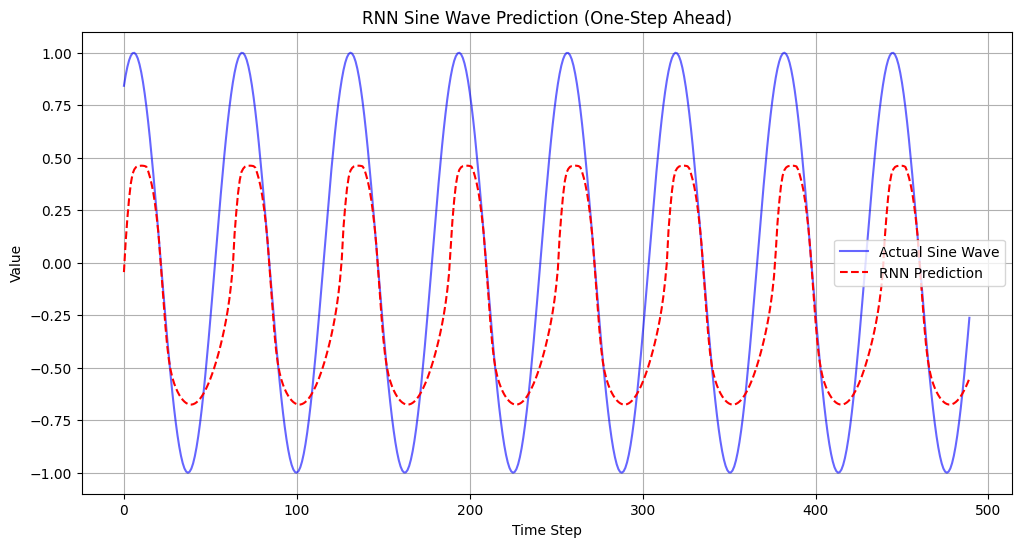

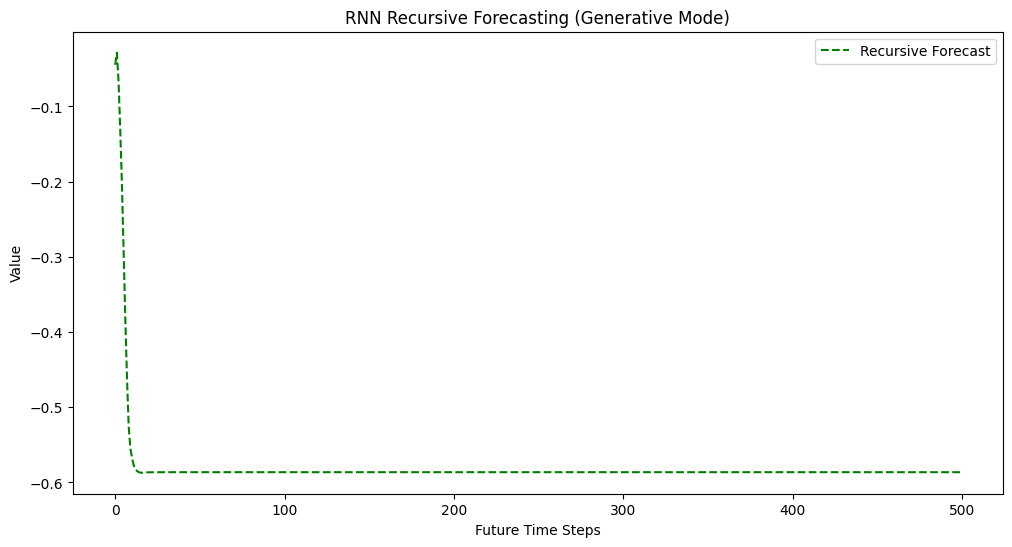

In [6]:
plot_predictions(model, X_train, Y_train, seq_length)
plot_recursive_forecast(model, X_train[0], n_steps_to_forecast=500)

I have had runs where this RNN works just fine and the model does a good job on predicting the wave. Here it seems to have been "dropped in" on a saddle point because the loss functions were not really changing the first 8 epochs or so. But even with this undertrained network we can see that it can learn the sine sequence fairly ok. 

In the original RNN papers sigmoid was the standard for activation functions, so I also trained a model using that to see how it fares. Clearly, this problem is very simple and even poorly implemented vanilla RNN's are able to crush it. Still cool to see that is able to recursively generate a sine wave to any length that we demand. 

In [7]:
class tanhRNN(RNN):
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer.forward(x)
            if i < len(self.layers) - 1:
                orig_shape = x.shape
                x = np.array([obj.tanh() for obj in x.ravel()]).reshape(orig_shape)
        return x

tanh_model = tanhRNN(1, [8,4], 1)
train(tanh_model, X_train, Y_train, epochs=10, lr=0.01)

Epoch 1, Loss: 0.419066
Epoch 2, Loss: 0.189379
Epoch 3, Loss: 0.082401
Epoch 4, Loss: 0.037723
Epoch 5, Loss: 0.020192
Epoch 6, Loss: 0.007122
Epoch 7, Loss: 0.001806
Epoch 8, Loss: 0.001524
Epoch 9, Loss: 0.001386
Epoch 10, Loss: 0.001269


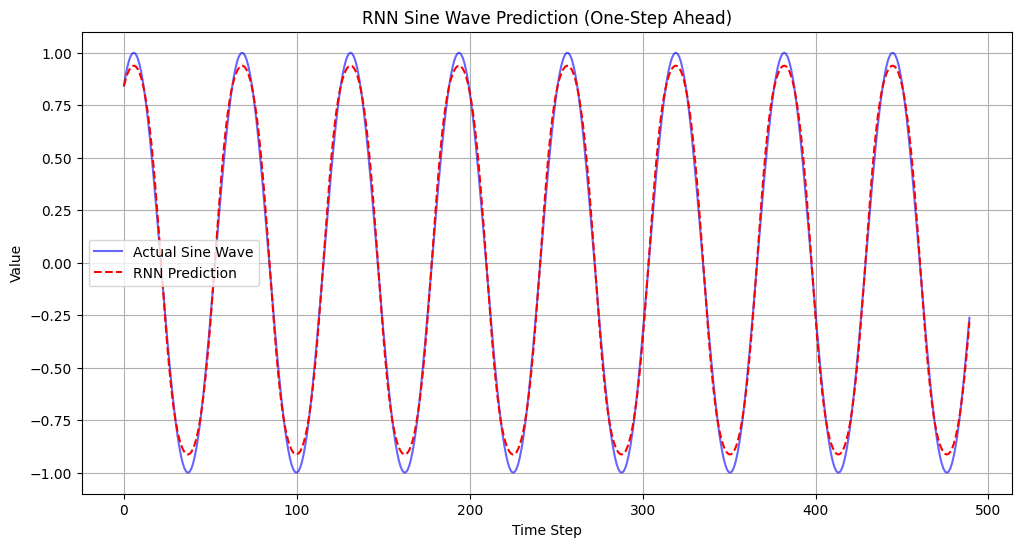

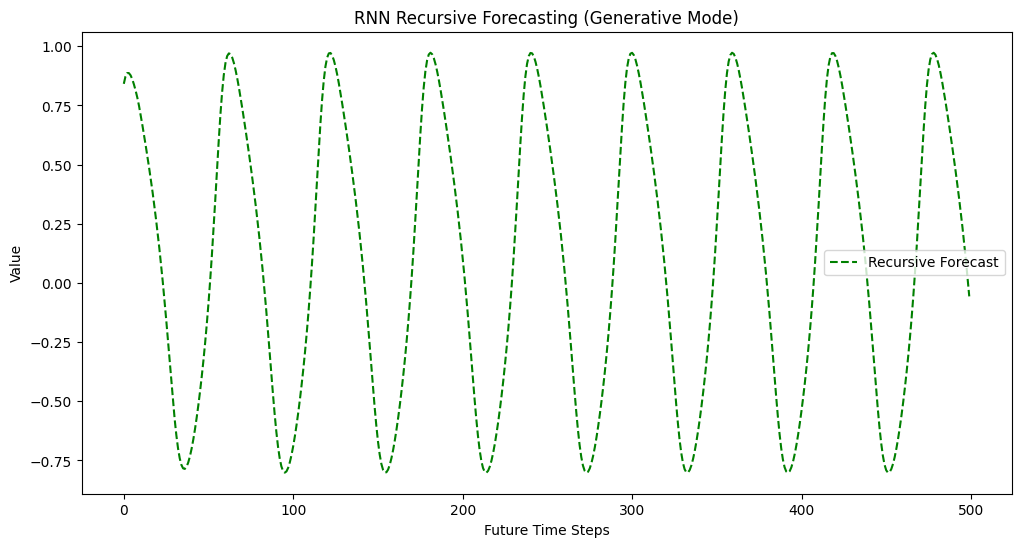

In [8]:
plot_predictions(tanh_model, X_train, Y_train, seq_length)
plot_recursive_forecast(tanh_model, X_train[0], n_steps_to_forecast=500)

## Long Short-Term Memory

Really good source: https://colah.github.io/posts/2015-08-Understanding-LSTMs/

- RNNs struggle with using information from a while ago. As the hidden states update, they more or less "forget" the initial info
- The LSTM introduces a cell state $C_t$ which gets fed to every layer like the previous hidden state, but it has a very few interactions so it can just flow mostly unchanged
- Gates are ways to optionally alter the information of the cell state
    - Gates use a sigmoid function to output numbers in $(0,1)$ which corresponds to how much information should be let through
- LSTM has 3 gates:
    - Forget Gate: It takes in $h_{t-1}$ and $x_t$. A 1 means that we keep all of this info, a 0 means you keep none.
        - Mathematically: $f_t =\sigma (W_f \cdot [h_{t-1},x_t]+b_f)$ where $[\cdot, \cdot]$ is concatenation
    - Input gate: decides which values we updateIt consists of two inputs:
        -   $i_t = \sigma \left( W_i \cdot [h_{t-1}, x_t] + b_i \right)$ which decides which values to update
        -  $\tilde{C}_t = \tanh \left( W_C \cdot [h_{t-1}, x_t] + b_C \right)$ which is a vector of candidate values that could be added to the cell state
    - Output gate: decides what to output as the hidden state, which also has 2 parts:
        - $o_t =\sigma(W_o[h_{t-1},x_t]+b_0)$ decides which part of the cell state to output as the hidden state
        - $h_t=o_t \cdot tanh(C_t)$, the hidden state that we pass to the next layer
- The cell state goes from $C_{t-1}$ to $f_t*C_{t-1}$ (forgetting old info) to $f_t*C_{t-1} + i_t * \tilde{C}_t$ (adding new info)
- The diagrams in the blog I linked are really good to visualize this whole mess
- Intuitively, we have a vector that we slightly modify according to new bits of information and then keep passing that along the network. This represents the memory of the network.
- RNNs struggle with keeping long term information partly because we override their memory (hidden state) at every step. LSTM addresses that

## LSTM Code

Here we will use PyTorch instead of the autograd that I implemented. I kind of wanted to train the model on some more complicated tasks where the inefficiencies of what I was doing would've made things impractical. 

In [3]:
import torch
import torch.nn as nn

In [14]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        
        self.C = torch.zeros(1, hidden_dim)
        self.hidden_state = torch.zeros(1, hidden_dim)

        # Originally had a much more naive weight init, but as we scaled the complexity of the problem it became insufficient so Glorot was used
        fan_in = input_dim + hidden_dim
        std = 1.0 / np.sqrt(fan_in)
        self.W_f = nn.Parameter(torch.randn(hidden_dim, fan_in) * std)
        self.b_f = nn.Parameter(torch.zeros(1, hidden_dim))
        self.W_i = nn.Parameter(torch.randn(hidden_dim, fan_in) * std)
        self.b_i = nn.Parameter(torch.zeros(1, hidden_dim))
        self.W_c = nn.Parameter(torch.randn(hidden_dim, fan_in) * std)
        self.b_c = nn.Parameter(torch.zeros(1, hidden_dim))
        self.W_o = nn.Parameter(torch.randn(hidden_dim, fan_in) * std)
        self.b_o = nn.Parameter(torch.zeros(1, hidden_dim))
        

    def forward(self, x):
        h_concat_x = torch.cat([self.hidden_state,x], dim=1)
        
        f_t = torch.sigmoid(h_concat_x @ self.W_f.T + self.b_f)
        i_t = torch.sigmoid(h_concat_x @ self.W_i.T + self.b_i)
        candidates_t = torch.tanh(h_concat_x @ self.W_c.T + self.b_c)
        o_t = torch.sigmoid(h_concat_x @ self.W_o.T + self.b_o)

        self.C = self.C * f_t + candidates_t * i_t
        self.hidden_state = o_t * torch.tanh(self.C)

        return self.C, self.hidden_state

So now we can start messing with the model and see what it is capable of. One task that I saw was kind of cool was this: we have an array, we pick two indices, our output is the sum of the values at those indices. A traditional network would fail at this since it has no concept of order in the input. 

*Everything below is mostly AI generated code* 

In [6]:
class LSTMModel(nn.Module):
    """Wraps the hand-written LSTM cell with a linear output layer."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = LSTM(input_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, output_dim)

    def reset_state(self):
        self.lstm.C = torch.zeros_like(self.lstm.C)
        self.lstm.hidden_state = torch.zeros_like(self.lstm.hidden_state)

    def forward(self, sequence):
        """sequence: (seq_len, input_dim) tensor"""
        for t in range(sequence.shape[0]):
            x_t = sequence[t].unsqueeze(0)          # (1, input_dim)
            _, h = self.lstm(x_t)
        return self.linear(h)                        # (1, output_dim)


def generate_masked_sum_data(n_samples, seq_length, rng=None):
    """Each sample is (seq_length, 2): column 0 = random value, column 1 = mask.
    Exactly 2 positions have mask=1; target = sum of the two masked values."""
    if rng is None:
        rng = np.random.default_rng()
    X = np.zeros((n_samples, seq_length, 2))
    Y = np.zeros((n_samples, 1))
    for i in range(n_samples):
        values = rng.uniform(-1, 1, size=seq_length)
        mask_idx = rng.choice(seq_length, size=2, replace=False)
        mask = np.zeros(seq_length)
        mask[mask_idx] = 1.0
        X[i, :, 0] = values
        X[i, :, 1] = mask
        Y[i, 0] = values[mask_idx].sum()
    return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)


def train_lstm(model, X, Y, epochs=10, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0.0
        for i in range(len(X)):
            model.reset_state()

            seq = X[i]                               # (seq_len,) or (seq_len, D)
            if seq.dim() == 1:
                seq = seq.unsqueeze(-1)              # (seq_len, 1) for 1-D inputs
            target = Y[i].unsqueeze(0) if Y[i].dim() == 0 else Y[i].unsqueeze(0)

            pred = model(seq)                        # (1, output_dim)
            loss = criterion(pred, target)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # detach cell / hidden state so next sample starts fresh graph
            model.lstm.C = model.lstm.C.detach()
            model.lstm.hidden_state = model.lstm.hidden_state.detach()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(X):.6f}")

As we can see below, the model gets the general idea of the rule.

Epoch 1/30, Loss: 0.662817
Epoch 2/30, Loss: 0.608908
Epoch 3/30, Loss: 0.532008
Epoch 4/30, Loss: 0.433108
Epoch 5/30, Loss: 0.349722
Epoch 6/30, Loss: 0.289503
Epoch 7/30, Loss: 0.259204
Epoch 8/30, Loss: 0.236457
Epoch 9/30, Loss: 0.214276
Epoch 10/30, Loss: 0.191049
Epoch 11/30, Loss: 0.173611
Epoch 12/30, Loss: 0.158751
Epoch 13/30, Loss: 0.142566
Epoch 14/30, Loss: 0.128533
Epoch 15/30, Loss: 0.116480
Epoch 16/30, Loss: 0.106410
Epoch 17/30, Loss: 0.099149
Epoch 18/30, Loss: 0.092568
Epoch 19/30, Loss: 0.078547
Epoch 20/30, Loss: 0.066999
Epoch 21/30, Loss: 0.062093
Epoch 22/30, Loss: 0.056451
Epoch 23/30, Loss: 0.053222
Epoch 24/30, Loss: 0.048958
Epoch 25/30, Loss: 0.044753
Epoch 26/30, Loss: 0.041877
Epoch 27/30, Loss: 0.042978
Epoch 28/30, Loss: 0.038347
Epoch 29/30, Loss: 0.038510
Epoch 30/30, Loss: 0.034917


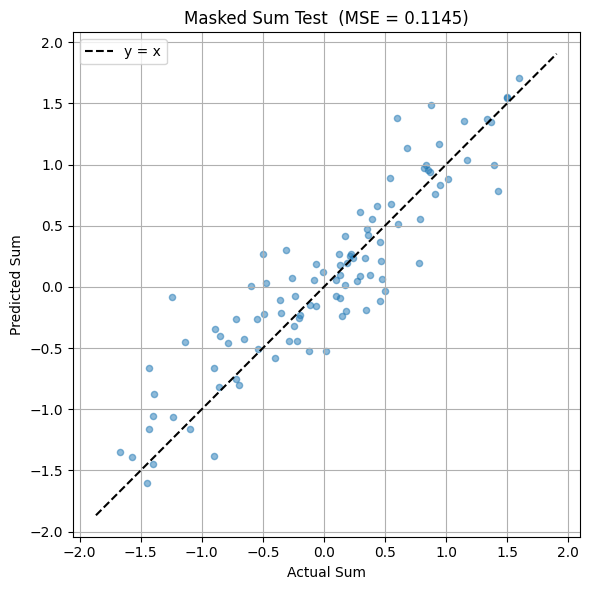

In [12]:
# --- Masked Sum Task ---
torch.manual_seed(42)
data_rng = np.random.default_rng(42)

X_train_ms, Y_train_ms = generate_masked_sum_data(500, seq_length=15, rng=data_rng)
X_test_ms, Y_test_ms = generate_masked_sum_data(100, seq_length=15, rng=data_rng)

masked_sum_model = LSTMModel(input_dim=2, hidden_dim=16, output_dim=1)
train_lstm(masked_sum_model, X_train_ms, Y_train_ms, epochs=30, lr=0.001)

# Evaluate on test set
masked_sum_model.eval()
preds = []
with torch.no_grad():
    for i in range(len(X_test_ms)):
        masked_sum_model.reset_state()
        pred = masked_sum_model(X_test_ms[i])
        preds.append(pred.item())

preds = np.array(preds)
actuals = Y_test_ms.numpy().ravel()
test_mse = np.mean((preds - actuals) ** 2)

plt.figure(figsize=(6, 6))
plt.scatter(actuals, preds, alpha=0.5, s=20)
mn, mx = min(actuals.min(), preds.min()) - 0.2, max(actuals.max(), preds.max()) + 0.2
plt.plot([mn, mx], [mn, mx], 'k--', label='y = x')
plt.xlabel('Actual Sum')
plt.ylabel('Predicted Sum')
plt.title(f'Masked Sum Test  (MSE = {test_mse:.4f})')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

Also we train it on sine wave to see how it performs. Unsurprisingly, it is pretty spot on with this task. 

/Users/artemkiryukhin/Desktop/Code/ML/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/10, Loss: 0.235368
Epoch 2/10, Loss: 0.014173
Epoch 3/10, Loss: 0.001595
Epoch 4/10, Loss: 0.000479
Epoch 5/10, Loss: 0.000531
Epoch 6/10, Loss: 0.000847
Epoch 7/10, Loss: 0.002584
Epoch 8/10, Loss: 0.005338
Epoch 9/10, Loss: 0.001440
Epoch 10/10, Loss: 0.000839


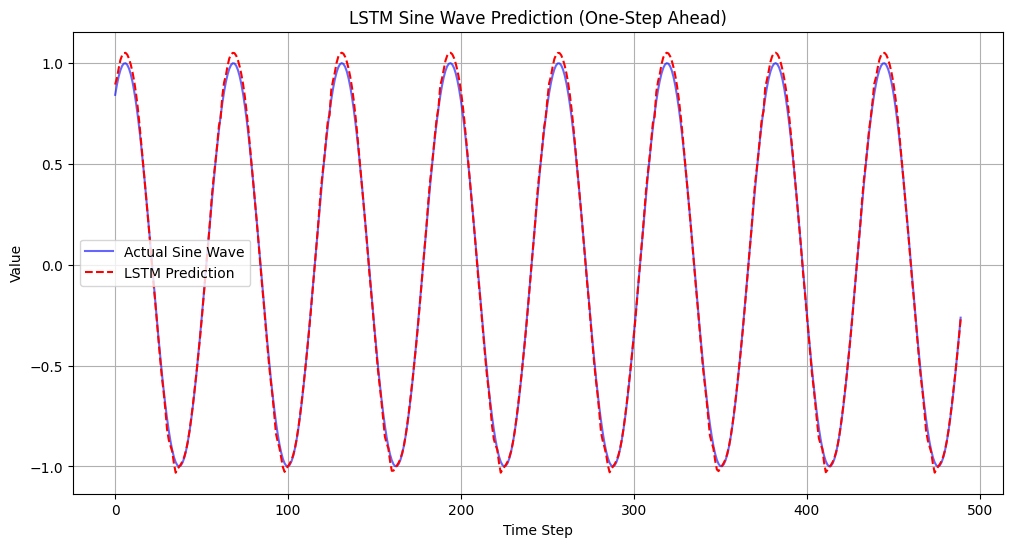

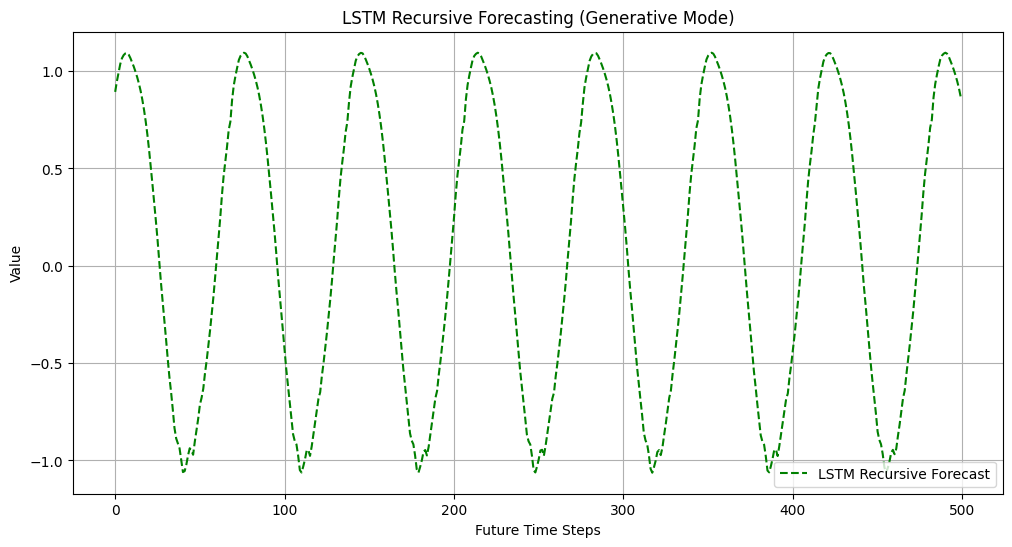

In [13]:
# --- Sine Wave Task (using the LSTM cell) ---
torch.manual_seed(42)

# Reuse the sine data generated earlier (X_train, Y_train from cell above)
X_sine = torch.tensor(np.array(X_train), dtype=torch.float32)   # (N, seq_length)
Y_sine = torch.tensor(np.array(Y_train), dtype=torch.float32)   # (N,)

sine_model = LSTMModel(input_dim=1, hidden_dim=16, output_dim=1)
train_lstm(sine_model, X_sine, Y_sine, epochs=10, lr=0.001)

# --- One-step-ahead prediction plot ---
sine_model.eval()
one_step_preds = []
with torch.no_grad():
    for i in range(len(X_sine)):
        sine_model.reset_state()
        seq = X_sine[i].unsqueeze(-1)               # (seq_len, 1)
        pred = sine_model(seq)
        one_step_preds.append(pred.item())

plt.figure(figsize=(12, 6))
plt.plot(Y_sine.numpy(), label='Actual Sine Wave', color='blue', alpha=0.6)
plt.plot(one_step_preds, label='LSTM Prediction', color='red', linestyle='--')
plt.title('LSTM Sine Wave Prediction (One-Step Ahead)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# --- Recursive forecast ---
n_forecast = 500
initial_seq = X_sine[0].tolist()
current_seq = list(initial_seq)
forecast = []

with torch.no_grad():
    for _ in range(n_forecast):
        sine_model.reset_state()
        seq_tensor = torch.tensor(current_seq, dtype=torch.float32).unsqueeze(-1)
        pred = sine_model(seq_tensor)
        next_val = pred.item()
        forecast.append(next_val)
        current_seq.pop(0)
        current_seq.append(next_val)

plt.figure(figsize=(12, 6))
plt.plot(forecast, label='LSTM Recursive Forecast', color='green', linestyle='--')
plt.title('LSTM Recursive Forecasting (Generative Mode)')
plt.xlabel('Future Time Steps')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## Handwriting Generation 

In the Graves paper that I linked above, they train an LSTM model to generate handwriting. They use a IAM handwriting dataset (which is not accessible anymore so I used https://github.com/brownvc/decoupled-style-descriptors) which contains the x,y positions of points (idk the criteria for which points they use) in the handwritten word and an eos bool flag that signals if the point is the end of a stroke. 

Instead of just predicting the (x,y,eos) tuple, Graves trains the model to predict a mixture of densities. This means that the model outputs $M$ set of means and std. for $M$ gaussian distributions that we use to predict the next point. More concretely the model outputs: (probability of eos, vector of weights of the $M$ distributions that sum up to 1, $M$ means, $M$ stds, $M$ rho's). Note that we are using bivariate gaussians so the means and stds are 2D. 

They also define a custom loss function: $\mathcal{L}(\mathbf{x}) = \sum_{t=1}^{T} -\log \left( \sum_{j} \pi_{t}^{j} \mathcal{N}(x_{t+1} | \mu_{t}^{j}, \sigma_{t}^{j}, \rho_{t}^{j}) \right) - \begin{cases} \log e_{t} & \text{if } (x_{t+1})_{3} = 1 \\ \log(1 - e_{t}) & \text{otherwise} \end{cases}$ which really is just a cross entropy function where we get our probabilities from the distributions that the model parameterized. Here $(x_{t+1}=1)$ just refers to if the point is end of stroke.

We also train using (x,y) offsets from the previous point in the sequence, since we are not really interested in absolute coordinates for the points (we can write the word anywhere on the page and it would be no less correct). Lastly, I train a much smaller model than they do in the paper, I just don't have the compute for anything bigger. 

*Code is fully AI generated*

In [5]:
import pickle
import os

data_dir = "../data/BRUSH"
drawings = []
labels = []

for writer_id in sorted(os.listdir(data_dir)):
    writer_path = os.path.join(data_dir, writer_id)
    if not os.path.isdir(writer_path):
        continue
    for file_name in sorted(os.listdir(writer_path)):
        if not file_name.isdigit():
            continue
        with open(os.path.join(writer_path, file_name), 'rb') as f:
            label, drawing, _ = pickle.load(f)
        drawings.append(torch.tensor(np.array(drawing), dtype=torch.float32))
        labels.append(label)

print(f"Loaded {len(drawings)} drawings")
print(f"Example shape: {drawings[0].shape}  (points times [x, y, pen_up])")

Loaded 27649 drawings
Example shape: torch.Size([689, 3])  (points times [x, y, pen_up])


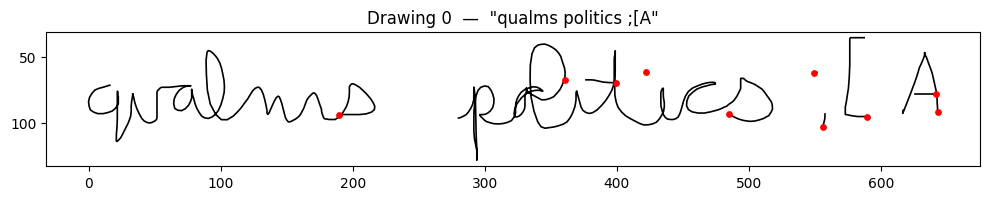

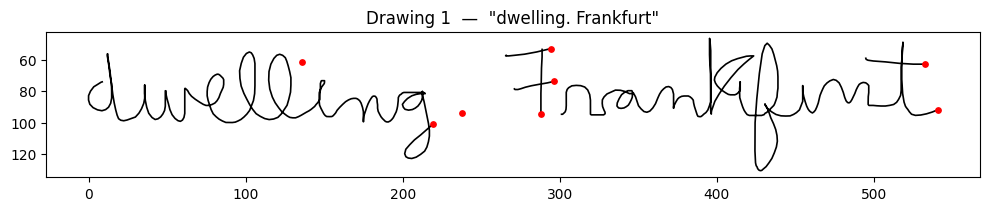

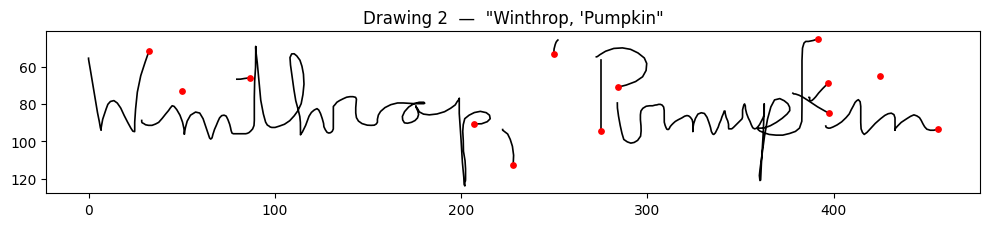

In [6]:
def plot_handwriting(drawing, label="", title="Handwriting Sample"):
    """Visualize a handwriting sample, highlighting end-of-stroke points."""
    coords = drawing[:, :2].numpy() if isinstance(drawing, torch.Tensor) else drawing[:, :2]
    pen_up = drawing[:, 2].numpy() if isinstance(drawing, torch.Tensor) else drawing[:, 2]

    x, y = coords[:, 0], coords[:, 1]

    stroke_start = 0
    fig, ax = plt.subplots(figsize=(10, 4))
    for i in range(len(pen_up)):
        if pen_up[i] == 1:
            ax.plot(x[stroke_start:i+1], y[stroke_start:i+1], color='black', linewidth=1.2)
            stroke_start = i + 1
    if stroke_start < len(pen_up):
        ax.plot(x[stroke_start:], y[stroke_start:], color='black', linewidth=1.2)

    # Overlay end-of-stroke points
    end_mask = pen_up == 1
    ax.scatter(x[end_mask], y[end_mask], color='red', s=15, zorder=3)

    ax.set_title(f'{title}  —  "{label}"')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

for i in range(3):
    plot_handwriting(drawings[i], label=labels[i], title=f"Drawing {i}")

In [27]:
# --- Model hyperparameters ---
INPUT_DIM = 3       # (x, y, pen_up)
HIDDEN_DIM = 256
M = 20              # number of mixture components

# --- Training hyperparameters ---
LR = 0.001
EPOCHS = 20
SEQ_LEN = 100       
CLIP_NORM = 5.0

In [8]:
class StrokeLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, M):
        super().__init__()
        self.M = M
        self.lstm = LSTM(input_dim, hidden_dim)
        # Output: 1 eos + M weights + 2M means + 2M stds + M correlations = 6M + 1
        self.linear = nn.Linear(hidden_dim, 6 * M + 1)

    def reset_state(self):
        self.lstm.C = torch.zeros_like(self.lstm.C)
        self.lstm.hidden_state = torch.zeros_like(self.lstm.hidden_state)

    def parse_output(self, h):
        y = self.linear(h)
        M = self.M

        eos_prob = torch.sigmoid(y[:, 0:1])
        weights  = torch.softmax(y[:, 1:1+M], dim=1)
        mu_x     = y[:, 1+M:1+2*M]
        mu_y     = y[:, 1+2*M:1+3*M]
        sigma_x  = torch.exp(torch.clamp(y[:, 1+3*M:1+4*M], min=-10, max=10))
        sigma_y  = torch.exp(torch.clamp(y[:, 1+4*M:1+5*M], min=-10, max=10))
        rho      = 0.95 * torch.tanh(y[:, 1+5*M:1+6*M])


        return eos_prob, weights, mu_x, mu_y, sigma_x, sigma_y, rho

    def forward(self, sequence):
        for t in range(sequence.shape[0]):
            x_t = sequence[t].unsqueeze(0)
            _, h = self.lstm(x_t)
        return self.parse_output(h)

In [9]:
def bivariate_gaussian_pdf(x, y, mu_x, mu_y, sigma_x, sigma_y, rho):
    z = ((x - mu_x) / sigma_x) ** 2 + \
        ((y - mu_y) / sigma_y) ** 2 - \
        2 * rho * (x - mu_x) * (y - mu_y) / (sigma_x * sigma_y)
    
    norm = 2 * np.pi * sigma_x * sigma_y * torch.sqrt(1 - rho ** 2)
    
    return torch.exp(-z / (2 * (1 - rho ** 2))) / norm

def stroke_loss(eos_probs, weights, mu_x, mu_y, sigma_x, sigma_y, rho, targets):
    x_next = targets[:, 0:1]
    y_next = targets[:, 1:2]
    pen_up = targets[:, 2:3]

    gauss = bivariate_gaussian_pdf(x_next, y_next, mu_x, mu_y, sigma_x, sigma_y, rho)
    mixture = torch.sum(weights * gauss, dim=1, keepdim=True)
    eos_term = pen_up * eos_probs + (1 - pen_up) * (1 - eos_probs)
    prob = mixture * eos_term

    return -torch.sum(torch.log(prob + 1e-15))

In [10]:
# Convert absolute coords to offsets (dx, dy), then normalize to mean 0 std 1
drawings_offsets = []
for d in drawings:
    offsets = d.clone()
    offsets[1:, :2] = d[1:, :2] - d[:-1, :2]
    offsets[0, :2] = 0.0
    drawings_offsets.append(offsets)

all_deltas = torch.cat([d[:, :2] for d in drawings_offsets])
xy_mean = all_deltas.mean(dim=0)
xy_std  = all_deltas.std(dim=0)

drawings_norm = []
for d in drawings_offsets:
    normed = d.clone()
    normed[:, :2] = (normed[:, :2] - xy_mean) / xy_std
    drawings_norm.append(normed)

print(f"Offset mean: {xy_mean}")
print(f"Offset std:  {xy_std}")

Offset mean: tensor([1.5282, 0.0825])
Offset std:  tensor([6.6416, 6.9197])


In [24]:
SUBSET_SIZE = 1000
subset_idx = torch.randperm(len(drawings_norm))[:SUBSET_SIZE]
drawings_sub = [drawings_norm[i] for i in subset_idx]
print(f"Training on {len(drawings_sub)} / {len(drawings_norm)} drawings")

Training on 1000 / 27649 drawings


In [28]:
from tqdm.notebook import tqdm

torch.manual_seed(42)
stroke_model = StrokeLSTM(INPUT_DIM, HIDDEN_DIM, M)
optimizer = torch.optim.Adam(stroke_model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    total_loss = 0.0
    n_chunks = 0
    indices = torch.randperm(len(drawings_sub))

    for idx in tqdm(indices, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        drawing = drawings_sub[idx]
        stroke_model.reset_state()

        for start in range(0, len(drawing) - 1, SEQ_LEN):
            end = min(start + SEQ_LEN, len(drawing) - 1)

            all_eos, all_w, all_mu_x, all_mu_y = [], [], [], []
            all_sx, all_sy, all_rho = [], [], []
            targets = []

            for t in range(start, end):
                x_t = drawing[t].unsqueeze(0)
                _, h = stroke_model.lstm(x_t)
                eos, w, mu_x, mu_y, sx, sy, rho = stroke_model.parse_output(h)

                all_eos.append(eos)
                all_w.append(w)
                all_mu_x.append(mu_x)
                all_mu_y.append(mu_y)
                all_sx.append(sx)
                all_sy.append(sy)
                all_rho.append(rho)
                targets.append(drawing[t + 1])

            all_eos  = torch.cat(all_eos)
            all_w    = torch.cat(all_w)
            all_mu_x = torch.cat(all_mu_x)
            all_mu_y = torch.cat(all_mu_y)
            all_sx   = torch.cat(all_sx)
            all_sy   = torch.cat(all_sy)
            all_rho  = torch.cat(all_rho)
            targets  = torch.stack(targets)

            loss = stroke_loss(all_eos, all_w, all_mu_x, all_mu_y, all_sx, all_sy, all_rho, targets)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(stroke_model.parameters(), max_norm=CLIP_NORM)
            optimizer.step()

            stroke_model.lstm.C = stroke_model.lstm.C.detach()
            stroke_model.lstm.hidden_state = stroke_model.lstm.hidden_state.detach()

            total_loss += loss.item()
            n_chunks += 1


    # Print per-parameter gradient stats
    avg_loss = total_loss / n_chunks
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")


Epoch 1/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/20, Loss: 24.6874


Epoch 2/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/20, Loss: -14.2850


Epoch 3/20:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 18/20, Loss: -53.8766


Epoch 19/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 19/20, Loss: -54.2606


Epoch 20/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 20/20, Loss: -55.8604


In [29]:
torch.save(stroke_model.state_dict(), "stroke_lstm_model.pth")

In the paper they somehow got the loss to $\approx -1400$, I am a bit off with my tiny model. Let's see if that is reflected in the quality of the handwriting

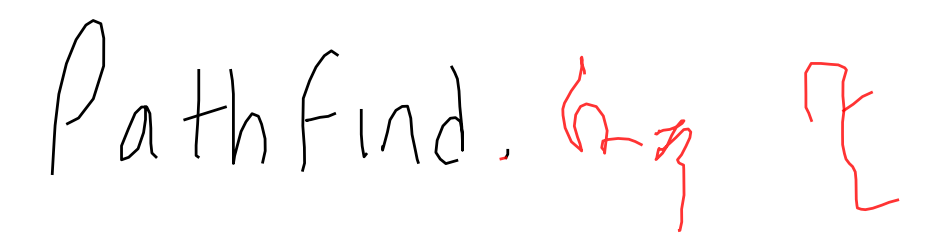

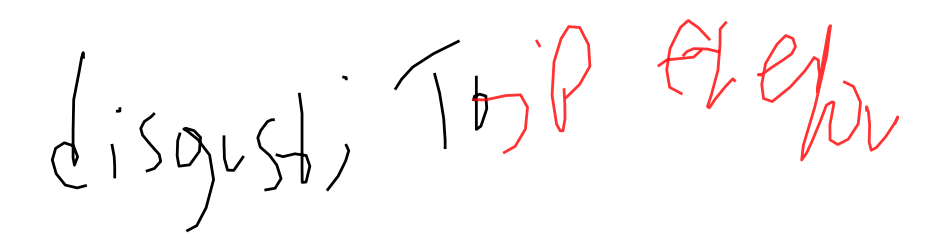

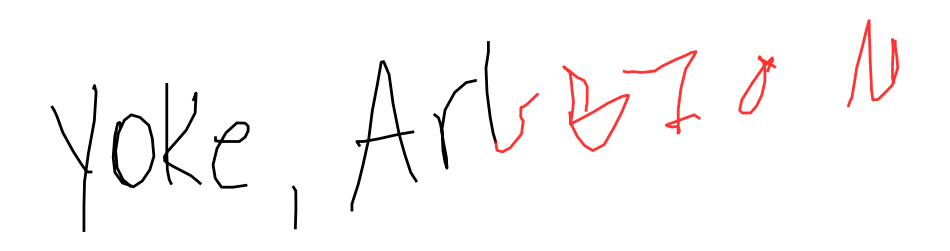

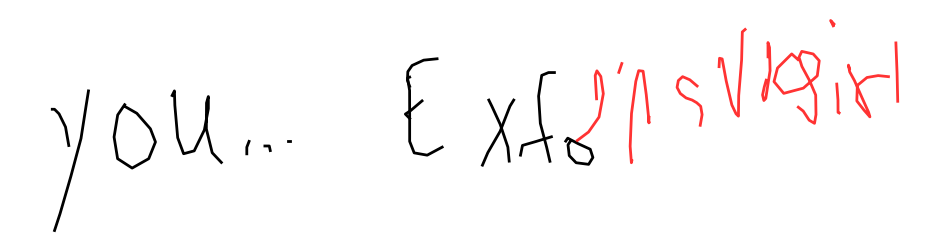

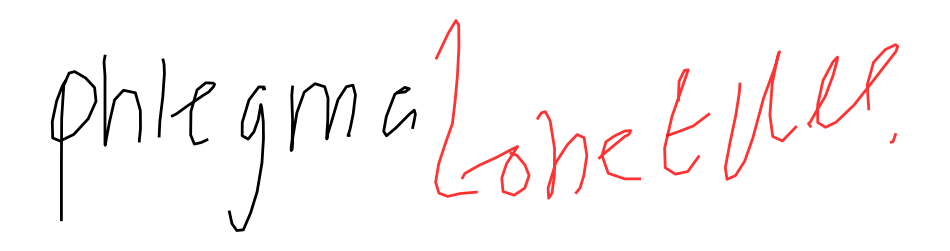

In [43]:
def plot_stroke_data(data, color='black', alpha=1.0, linewidth=2):
    """Helper to plot handwriting strokes based on the pen-up bit (3rd column)."""
    # Split into separate strokes whenever the 3rd column (pen-up) is > 0
    data_np = data.cpu().numpy()
    # The split happens after the pen-up event
    strokes = np.split(data_np, np.where(data_np[:, 2] > 0)[0] + 1)
    
    for s in strokes:
        if len(s) > 1:
            # We plot -s[:, 1] because handwriting Y-coords usually increase downwards
            plt.plot(s[:, 0], -s[:, 1], color=color, alpha=alpha, linewidth=linewidth)

def complete_drawing(model, drawing_norm, drawing_abs, label, context_frac=0.5):
    split = int(len(drawing_norm) * context_frac)

    # 1. Feed context through the model
    model.reset_state()
    model.eval() 
    with torch.no_grad():
        for t in range(split):
            x_t = drawing_norm[t].unsqueeze(0)
            _, h = model.lstm(x_t)

        # 2. Autoregressively generate the rest
        generated = []
        prev = drawing_norm[split - 1]
        for _ in range(len(drawing_norm) - split):
            x_t = prev.unsqueeze(0)
            _, h = model.lstm(x_t)
            eos, w, mu_x, mu_y, sx, sy, rho = model.parse_output(h)

            # Sample mixture component
            k = torch.multinomial(w[0], 1).item()

            # Sample (dx, dy)
            mu = torch.tensor([mu_x[0, k], mu_y[0, k]])
            cov = torch.tensor([
                [sx[0, k]**2,                   rho[0, k] * sx[0, k] * sy[0, k]],
                [rho[0, k] * sx[0, k] * sy[0, k], sy[0, k]**2]
            ])
            dx_dy = torch.distributions.MultivariateNormal(mu, cov).sample()

            # Sample pen-up
            pen = (torch.rand(1) < eos[0, 0]).float().item()

            prev = torch.tensor([dx_dy[0], dx_dy[1], pen])
            generated.append(prev)

    generated = torch.stack(generated)

    # 3. Build full sequence and denormalize
    full_norm = torch.cat([drawing_norm[:split], generated])
    full_offsets = full_norm.clone()
    full_offsets[:, :2] = full_offsets[:, :2] * xy_std + xy_mean

    # Convert to absolute coordinates
    completed = full_offsets.clone()
    completed[:, :2] = drawing_abs[0, :2] + torch.cumsum(full_offsets[:, :2], dim=0)

    # 4. Visualization
    context_part = completed[:split]
    generated_part = completed[split-1:] # Overlap one point to connect lines

    plt.figure(figsize=(12, 3))
    
    # Plot context in black
    plot_stroke_data(context_part, color='black', alpha=1.0)
    
    # Plot prediction in red
    plot_stroke_data(generated_part, color='red', alpha=0.8)

    #plt.title(f"Handwriting Generation: Black (Context) | Red (Prediction)")
    plt.axis('off')
    plt.show()
# Show a few examples from the training subset
for _ in range(5):
    idx = subset_idx[torch.randint(0, len(subset_idx), (1,)).item()].item()
    complete_drawing(stroke_model, drawings_norm[idx], drawings[idx], labels[idx])

Well... The bottom word gives me some hope. Still better than my handwriting.